[' ', '`', "'", '.', '-', '_', ',', '~', ':', '"', '^', '!', ';', '=', '+', '<', '>', '/', '\\', '?', '7', 'c', 'v', 'l', 'L', '(', ')', 'i', 'r', 't', '*', 'x', 'z', 'T', '|', '1', '4', 'f', 'J', 'Y', '}', 'j', 's', 'C', '[', ']', '{', 'n', 'u', 'F', '2', '3', 'y', 'I', 'o', 'V', 'a', 'e', '5', 'Z', 'h', 'k', 'X', 'E', 'U', 'P', 'S', '6', '9', 'K', 'm', 'p', 'A', 'H', '&', 'b', 'd', 'q', 'w', 'G', 'O', 'D', '#', '8', 'R', 'Q', '%', '0', 'g', 'B', 'N', '$', 'M', '@', 'W']
95
(512, 512)
(512, 512)


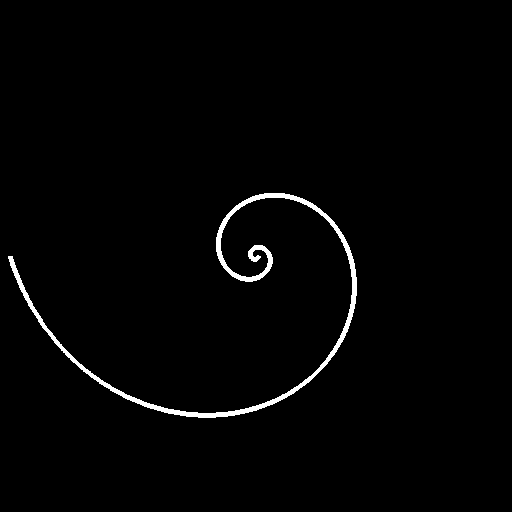

In [1]:
import sys
sys.path.append('../src')

from IPython.display import display, clear_output
from PIL import Image, ImageFont
import matplotlib.pyplot as plt
import numpy as np

from palette.symbol2value import get_asciis, symbols_sorted
from image.processing import preprocess_img
from rendering.image import render_symbols_img
from converters.img_converter import ImgConverter
from converters.line_heuristics.utils import get_char_width, get_line_height
from converters.tile.bin_2d import Tile2Symb2dBin
from converters.evaluation import img_similarity

# from diagnostics.artifact_manager import get_artifact_manager
# get_artifact_manager(debug=True)

# FONT = ImageFont.truetype("../fonts/OpenSans-Regular.ttf", 16)
FONT = ImageFont.truetype("../fonts/FiraCode-Regular.ttf", 16)

CHAR_SET = symbols_sorted(get_asciis(), FONT)[::1]
print(CHAR_SET)
print(len(CHAR_SET))
MAX_LINES = 12
line_height = get_line_height(CHAR_SET, FONT)
MAX_COLS = 40
col_width = get_char_width(FONT)
tile_converter = Tile2Symb2dBin(CHAR_SET, FONT)

IMG_PATH = "../imgs/test_fibonacci_spiral.png"
orig_img = Image.open(IMG_PATH).convert("L")
print(orig_img.size)
prep_img = preprocess_img(orig_img, contrast=1.5)
print(prep_img.size)
display(prep_img)

[[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '], [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '], [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '], [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '], [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'p', 'A', 'A', 'q', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '], [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'p', '_', '_', ' ', ' ', ')', 'p', ' ', ' ', ' ', ' ', ' ', ' ', ' '], ['M', '_', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ')', 'w', 'f', ' ', ' ', ' ', ']', ' ', ' ', ' ', ' ', ' ', ' ', ' '], [' ', ')', '@', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'A', ' ', ' ', ' ', ' ', ' ', ' ', ' '], [' ', ' ', ' ', '$', '_

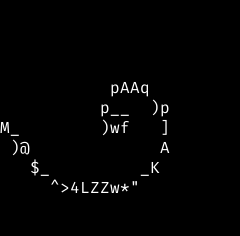

In [2]:
from converters.line_heuristics.greedy import GreedyLineSearch

line_converter = GreedyLineSearch(CHAR_SET, FONT)
res_arr = ImgConverter(line_converter, font=FONT).img2symbols(prep_img,
                                                   max_lines=MAX_LINES,
                                                   line_height=line_height,
                                                   max_cols=MAX_COLS,
                                                   col_width=col_width)
print(res_arr)
rendered = render_symbols_img(res_arr, FONT)
print(img_similarity(orig_img, rendered))
display(rendered)

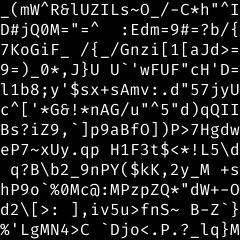

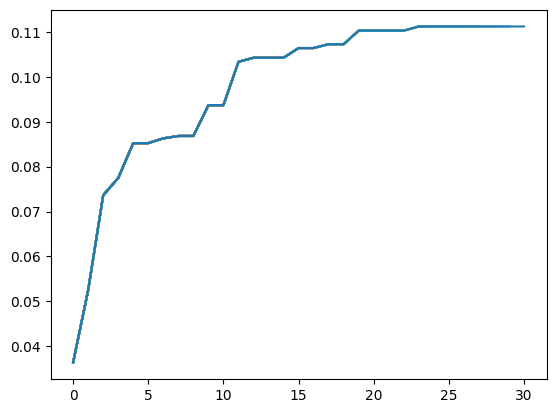

In [6]:
from converters.line_heuristics.random_search import RandomLineSearch

line_converter = RandomLineSearch(CHAR_SET, FONT, 150)
res_history = []
for res_arr in ImgConverter(line_converter, font=FONT).img2symbols_lazy(prep_img,
                                                             max_lines=MAX_LINES,
                                                             line_height=line_height,
                                                             max_cols=MAX_COLS,
                                                             col_width=col_width,
                                                             gens_per_step=5):
    rendered = render_symbols_img(res_arr, FONT)
    res_history.append(img_similarity(orig_img, rendered))
    clear_output()
    display(rendered)
    plt.plot(res_history)

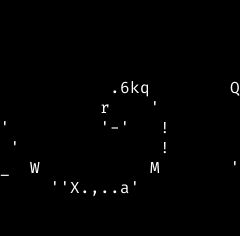

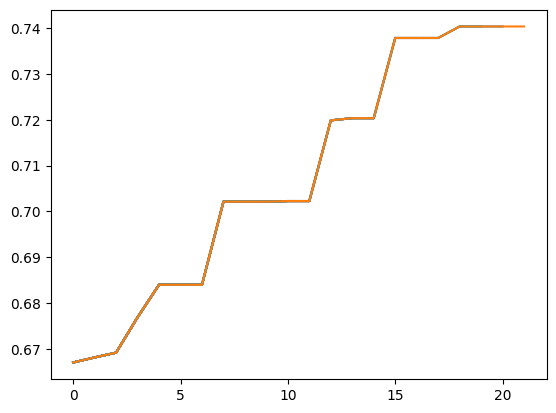

In [ ]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch

line_converter =  HarmonyLineSearch(CHAR_SET, FONT, generations=50, pop_count=10,
                                    mem_rate=0.9, pa_rate=0.1, pa=len(CHAR_SET) // 8,
                                    tile_converter=tile_converter)
res_history = []
for res_arr in ImgConverter(line_converter, font=FONT).img2symbols_lazy(prep_img,
                                                             max_lines=MAX_LINES,
                                                             line_height=line_height,
                                                             max_cols=MAX_COLS,
                                                             col_width=col_width,
                                                             gens_per_step=5):
    rendered = render_symbols_img(res_arr, FONT)
    res_history.append(img_similarity(orig_img, rendered))
    clear_output()
    display(rendered)
    plt.plot(res_history)

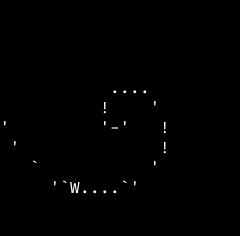

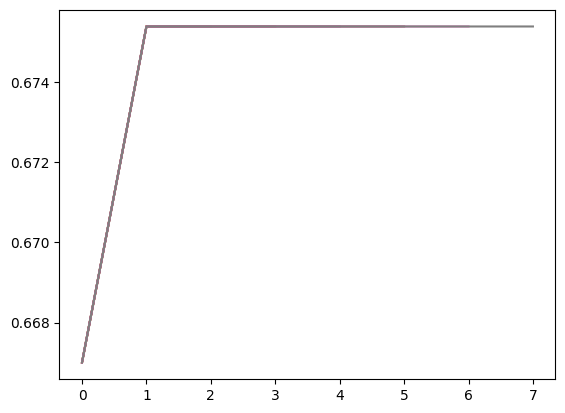

In [8]:
from converters.line_heuristics.genetic_search import GeneticLineSearch

line_converter =  GeneticLineSearch(CHAR_SET, FONT, generations=30, pop_count=50,
                                    tile_converter=tile_converter)
res_history = []
for res_arr in ImgConverter(line_converter, font=FONT).img2symbols_lazy(prep_img,
                                                             max_lines=MAX_LINES,
                                                             line_height=line_height,
                                                             max_cols=MAX_COLS,
                                                             col_width=col_width,
                                                             gens_per_step=5):
    rendered = render_symbols_img(res_arr, FONT)
    res_history.append(img_similarity(orig_img, rendered))
    clear_output()
    display(rendered)
    plt.plot(res_history)

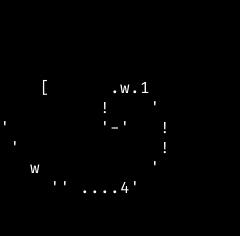

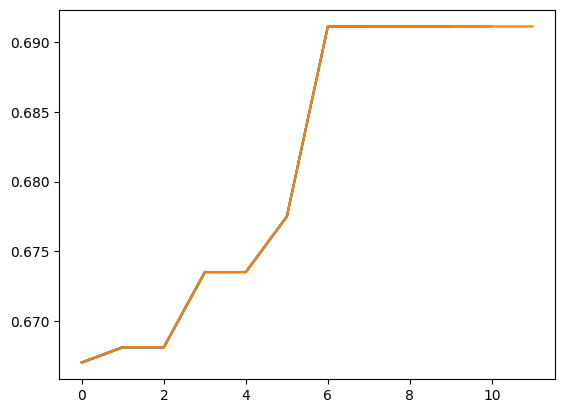

In [9]:
from converters.line_heuristics.pso_search import ParticleSwarmLineSearch

line_converter = ParticleSwarmLineSearch(CHAR_SET, FONT, generations=50, pop_count=10,
                                         innertion=2.0, cog_coeff=3.0, soc_coeff=3.0,
                                         tile_converter=tile_converter)
res_history = []
for res_arr in ImgConverter(line_converter, font=FONT).img2symbols_lazy(prep_img,
                                                             max_lines=MAX_LINES,
                                                             line_height=line_height,
                                                             max_cols=MAX_COLS,
                                                             col_width=col_width,
                                                             gens_per_step=5):
    rendered = render_symbols_img(res_arr, FONT)
    res_history.append(img_similarity(orig_img, rendered))
    clear_output()
    display(rendered)
    plt.plot(res_history)
